In [1]:
import os
import sys
import pandas as pd

current_dir = os.getcwd()

project_root = os.path.abspath(os.path.join(current_dir, "..", ".."))

if project_root not in sys.path:
    sys.path.append(project_root)

print(f"✅ Project root added: {project_root}")

try:
    from olist.order import Order
    orders = Order().get_training_data()
    print(f"🚀 Success! Training data loaded with {len(orders)} rows.")
except ModuleNotFoundError:
    print("❌ Still can't find the 'olist' package. Check your folder structure!")

✅ Project root added: /Users/ilos/code/inurekici.sc/projects/S14D3Ps--olist-analysis
🚀 Success! Training data loaded with 96353 rows.


# Siparişler - `review_score` Çok Değişkenli Regresyonu

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# Import modules
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

⚠️ Devam etmeden önce:
* 💾 Önceki ünitenin Siparişler çözümünü indirin
* 👥 `order_solution.py`'nin içeriğini `olist/order.py` dosyasına kopyalayıp yapıştırın

⚠️ `olist` havuzunuzda `order.py` dosyasındaki kod değişikliklerini commit etmeyi unutmayın!

👇 Öncelikle `orders` veri setini içeri aktarın

In [4]:
from olist.order import Order
orders = Order().get_training_data(with_distance_seller_customer=True)

Önceki analizimizi hatırlayalım:

Aşağıdaki 👇 korelasyon matrisi üzerinden, `review_score`'un çoğunlukla iki özellik ile ilişkili olduğunu görebiliriz: `wait_time` ve `delay_vs_expected`. Ancak, bu iki özellik de birbirleriyle yüksek oranda ilişkilidirler.

Bu alıştırmada, bir özelliğin etkisini ayırt etmek için `statsmodels` kullanacağız, **diğer özellikleri sabit tutarak**.

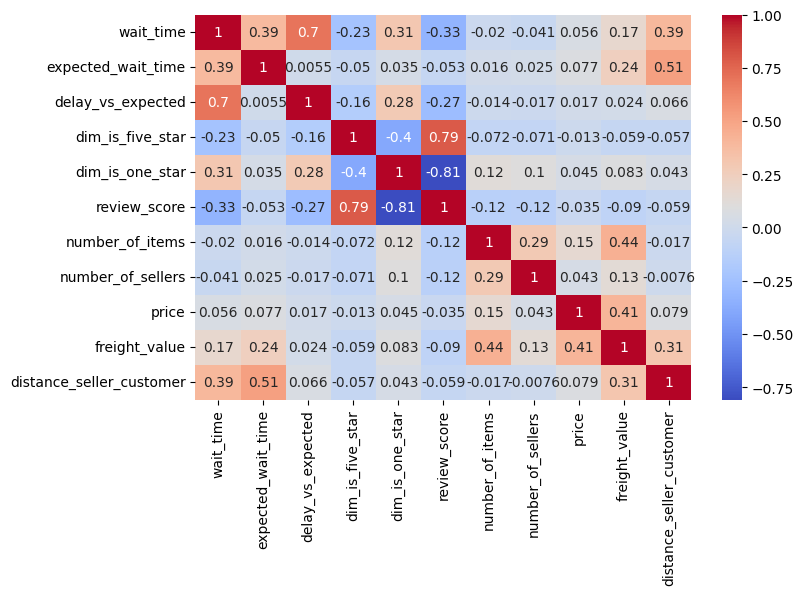

In [7]:
plt.figure(figsize = (8, 5))

sns.heatmap(
    orders.corr(numeric_only=True),
    cmap='coolwarm',
    annot=True,
    annot_kws={"size": 10}
);

## 1 - Tek Değişkenli Regresyon

❓ [statsmodels](https://www.statsmodels.org/stable/generated/statsmodels.formula.api.ols.html) ile `statsmodels.formula.api` kullanarak hızlı bir şekilde şunları oluşturun:
 - `model1`: `review_score`'un `wait_time` üzerinde ols regresyonu
 - `model2`: `review_score`'un `delay_vs_expected` üzerinde ols regresyonu

Her biri için `summary` tablosunu yazdırın ve sonuçları yorumlayin:
- Bu sonuçların seaborn regplot sonuçları ile nasıl eşleştiğini anladığınızdan emin olun
- Regresyon performans metriği `R-squared`, `individual regression coefficients`, `t-values`, `p-values` ve `95% confidence intervals`'ı okuyun

In [8]:
import statsmodels.formula.api as smf

***Model 1***:

In [ ]:
model1 = smf.ols('review_score ~ wait_time', data=orders).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.112
Model:                            OLS   Adj. R-squared:                  0.112
Method:                 Least Squares   F-statistic:                 1.204e+04
Date:                Thu, 01 Jan 2026   Prob (F-statistic):               0.00
Time:                        17:06:04   Log-Likelihood:            -1.5441e+05
No. Observations:               95872   AIC:                         3.088e+05
Df Residuals:                   95870   BIC:                         3.089e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.7236      0.006    727.904      0.0

Katsayı (coef): -0.0454. Bu şu demek: Müşterinin beklediği her 1 günlük artış, inceleme puanını ortalama 0.045 birim düşürüyor.

P-değeri (P>|t|): 0.000. Bu değer 0.05'ten çok küçük olduğu için wait_time ile review_score arasındaki ilişkinin şans eseri olmadığını, istatistiksel olarak anlamlı olduğunu kesinlikle söyleyebiliriz.

R-squared: 0.112. Müşteri puanlarındaki toplam değişimin yaklaşık %11'ini sadece bekleme süresiyle açıklayabiliyoruz. Geri kalan %89; ürün kalitesi, fiyat veya iletişim gibi diğer faktörlere bağlı.

***Model 2***:

In [11]:
model2 = smf.ols('review_score ~ delay_vs_expected', data=orders).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.074
Method:                 Least Squares   F-statistic:                     7681.
Date:                Thu, 01 Jan 2026   Prob (F-statistic):               0.00
Time:                        17:07:23   Log-Likelihood:            -1.5639e+05
No. Observations:               95872   AIC:                         3.128e+05
Df Residuals:                   95870   BIC:                         3.128e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             4.2121      0.00

Katsayı (coef): -0.0752. Bu çok kritik! Gecikilen her gün, puanı bekleme süresinden daha sert düşürüyor (0.045'e karşı 0.075). Yani müşteri beklemeye bir yere kadar razı ama vaat edilen sürenin aşılmasına (gecikmeye) çok daha tepkili.

P-değeri: 0.000. Yine istatistiksel olarak çok anlamlı.

R-squared: 0.074. Gecikme tek başına puan varyansının %7.4'ünü açıklıyor.

## 2 - Çok Değişkenli Regresyon

❓ Siparişe bir gün `delay_vs_expected` eklemenin `review_score` üzerindeki etkisi nedir, **`wait_time` sabit tutarak**? İki özellikten hangisi düşük `review_score` için en açıklayıcıdır?

Bu amaçla, `wait_time` ve `delay_vs_expected`'in özellikler (bağımsız değişkenler) olduğu ve `review_score`'un hedef (bağımlı değişken) olduğu bir OLS modeli `model3`'ü çalıştırın

***Model 3***:

In [12]:
model3 = smf.ols('review_score ~ wait_time + delay_vs_expected', data=orders).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.114
Model:                            OLS   Adj. R-squared:                  0.114
Method:                 Least Squares   F-statistic:                     6191.
Date:                Thu, 01 Jan 2026   Prob (F-statistic):               0.00
Time:                        17:11:18   Log-Likelihood:            -1.5426e+05
No. Observations:               95872   AIC:                         3.085e+05
Df Residuals:                   95869   BIC:                         3.086e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             4.6502      0.00

wait_time (Model 1): $-0.0454$

wait_time (Model 3): $-0.0383$ 

(Mutlak değerce azaldı, yani sıfıra yaklaştı!)


delay_vs_expected (Model 2): $-0.0752$

delay_vs_expected (Model 3): $-0.0205$ 

(Mutlak değerce ciddi oranda azaldı)

İlk modellerde, örneğin wait_time değişkeni, aslında içindeki "gecikme" payının da suçunu üstleniyordu. Çok değişkenli modelde her iki değişkeni yan yana koyduğumuzda istatistiksel olarak şunu demiş olduk: "Gecikme süresi aynı kalmak şartıyla (sabit tutarak), sadece bekleme süresindeki 1 günlük artış puanı ne kadar etkiler?"

wait_time hala en baskın suçlu ($-0.0383$), çünkü mutlak değerce hala daha büyük.

delay_vs_expected katsayısının $-0.07$'den $-0.02$'ye düşmesi, gecikmenin yarattığı negatif etkinin bir kısmının zaten toplam bekleme süresi içinde "hissedildiğini" gösteriyor.

----
👉 Çok değişkenli regresyon, bir özelliğin etkisini izole etmek ve diğer özelliklerin etkisini kontrol etmek için bize izin verir. Bu yeni katsayılara **`kısmi korelasyon katsayıları`** denir. 

❓ Yukarıda *seaborn* ile hesaplanan **basit regresyon** katsayıları ile fark görebilir misiniz? 

❓ `wait_time` ve `delay_vs_expected` için göreceli eğimler hakkında ne söyleyebilirsiniz?

<details>
    <summary>- 💡 Solution 💡-</summary>

- Holding `wait_time` constant, each additional day of `delay` reduces the review_score on average by 0.0205 [0.023 - 0.018] points
- Holding `delay` constant, each additional day of `wait_time` reduces the review_score on average by 0.0383 [0.039 - 0.037] points

Contrary to what was found with the simple bivariate correlation analysis, `delay` is actually less impactful than `wait_time` in driving lower `review_score`! This interesting finding demonstrates the importance of multi-variate regression to remove the potential impact of confounding factors

---
❌ R-squared oldukça düşük: review_score varyasyonlarının en fazla %12'si `wait_time` ve `delay_vs_expected`'in birleşik varyasyonları tarafından açıklanır.

✅ Doğrusal regresyonun açıklanabilirliğini iyileştirmek için regresyonumuza daha fazla özellik eklemeyi deneyelim.

Sonraki adımlarda `orders` veri setinden daha fazla özellik içeren yeni bir OLS `model4` oluşturacağız. Adım adım size rehberlik edeceğiz.

📝 <u>Not</u>: bir **`Çok Değişkenli Doğrusal Regresyon`** aynı zamanda **`Ordinary Least Squares`** yöntemi olarak da adlandırılır çünkü bu modelde **`MSE Ortalama Kare Hatalar`**'ı minimize etmek istiyoruz

***Model 4***:

❓ Hangi özellikleri göz önünde almak istersiniz?

👉 Bu özelliklerle bir `features` DataFrame oluşturun.

- ⚠️ **veri sızıntısı** oluşturmayın: `review_score`'tan doğrudan türetilen özellikleri eklemeyin
- ⚠️ Birbirleriyle mükemmel bir şekilde ilişkili olan iki özellik eklemeyin

In [ ]:
selected_columns = [
    'wait_time',
    'delay_vs_expected',
    'number_of_items',
    'number_of_sellers',
    'price',
    'freight_value',
    'review_score'
]
features = orders[selected_columns].copy()

print("Eksik Değer Sayısı:\n", features.isnull().sum())

Eksik Değer Sayısı:
 wait_time            0
delay_vs_expected    0
number_of_items      0
number_of_sellers    0
price                0
freight_value        0
review_score         0
dtype: int64


In [15]:
features.head()

,wait_time,delay_vs_expected,number_of_items,number_of_sellers,price,freight_value,review_score
0,8.436574,0.0,1,1,29.99,8.72,4
1,13.782037,0.0,1,1,118.70,22.76,4
2,9.394213,0.0,1,1,159.90,19.22,5
3,13.208750,0.0,1,1,45.00,27.20,5
4,2.873877,0.0,1,1,19.90,8.72,5


Sonra, özellikleri "standardize" edeceğiz.

**Bu ne anlama gelir?**

⚖️  Her özellik $X_i$'yi ilgili z-score'una $Z_i = \frac{X_i - \mu_i}{\sigma_i}$ dönüştüreceğiz.

**Neden?**

Bir `çok değişkenli doğrusal regresyon`'da, her özelliğin hedef üzerindeki etkisini ölçmeye çalışıyoruz.
    
⚠️ Ölçek etkileri nedeniyle, bazı özellikler yanlışlıkla diğerlerinden daha önemli olarak görülecektir
    
> Örneğin: "yatak odası sayısı" özelliği 1 ile 5 arasında ve "yüzey" özelliği 20 ile 200 m² arasında ise, bu iki özelliğin aralıkları oldukça farklıdır...

Bu nedenle kısmi regresyon katsayıları $\beta_i$'yi birlikte karşılaştırabilmek için standardize ederiz. Aksi takdirde, $\beta_i$ aynı boyuta sahip olmayacak, yani elmalar (örn. "gün başına review-yıldızlar") ile portakalları (örn. "BRL başına review-yıldızlar") karşılaştırmış olacaksınız!

📅 Makine Öğrenmesi Algoritmalarını keşfettiğimizde, herhangi bir hedefi tahmin etmeye çalışmadan önce bazı ölçekleme işlemleri gerçekleştirmemiz gerekecektir.

👉  Özelliklerinizi standardize edin:

1. `features` DataFrame'inizden başlayın
1. `mean`'i çıkarın
1. Standart sapma `std`'ye bölün.
1. Sonucu `orders_standardized` değişkenine kaydedin.
1. Son olarak, `orders['review_score']` sütununu `orders_standardized`'e kopyalayın.

2. ve 3. adımları basit bir matematiksel işlem olarak yazabilirsiniz, hatta DataFrames ile de. Pandas bunu anlamak için yeterince akıllıdır.

<details>
  <summary><i>İpucu</i></summary>

  ```python
  features - features.mean() / features.std()
  ```

</details>

👉 `model4`'ü oluşturun ve eğitin.

In [16]:
features_only = features.drop(columns=['review_score'])

In [18]:
orders_standardized = (features_only - features_only.mean()) / features_only.std()

In [20]:
orders_standardized['review_score'] = features['review_score']

In [21]:
print("Yeni Ortalamalar (0'a çok yakın olmalı):\n", orders_standardized.mean().round(2))
print("\nYeni Standart Sapmalar (1 olmalı):\n", orders_standardized.std().round(2))

Yeni Ortalamalar (0'a çok yakın olmalı):
 wait_time            0.00
delay_vs_expected    0.00
number_of_items     -0.00
number_of_sellers    0.00
price                0.00
freight_value       -0.00
review_score         4.16
dtype: float64

Yeni Standart Sapmalar (1 olmalı):
 wait_time            1.00
delay_vs_expected    1.00
number_of_items      1.00
number_of_sellers    1.00
price                1.00
freight_value        1.00
review_score         1.29
dtype: float64


In [23]:
formula = "review_score ~ wait_time + delay_vs_expected + number_of_items + number_of_sellers + price + freight_value"

model4 = smf.ols(formula, data=orders_standardized).fit()

print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.141
Model:                            OLS   Adj. R-squared:                  0.141
Method:                 Least Squares   F-statistic:                     2623.
Date:                Thu, 01 Jan 2026   Prob (F-statistic):               0.00
Time:                        17:25:39   Log-Likelihood:            -1.5280e+05
No. Observations:               95872   AIC:                         3.056e+05
Df Residuals:                   95865   BIC:                         3.057e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             4.1555      0.00

---
❓ En önemli özellikler nelerdir? (onları iyi görselleştirmek için `.plot(kind='barh')` ile bir çubuk grafik yapın)
- Genel regresyon performansı nasıl değişti?
- Bu regresyon istatistiksel olarak anlamlı mıdır?

In [24]:
coefficients = model4.params.drop('Intercept').sort_values(ascending=True)

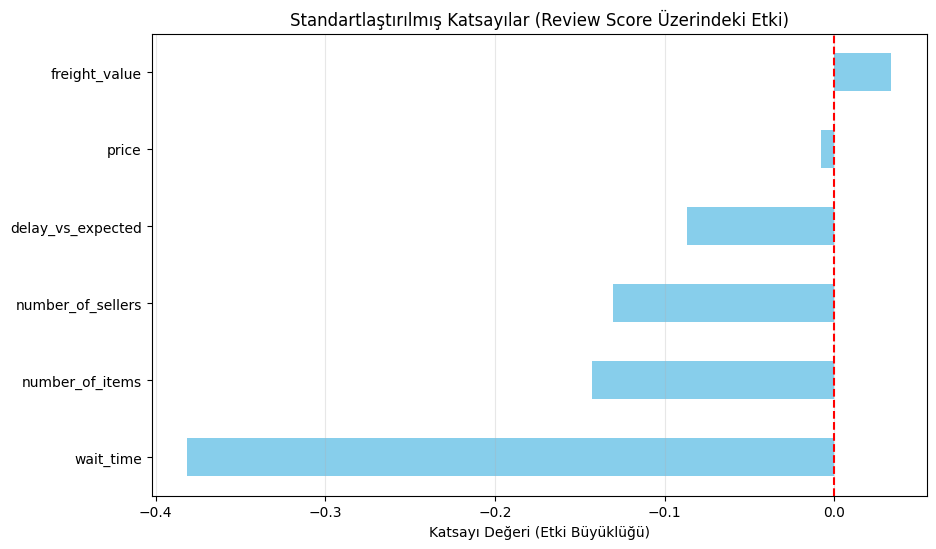

In [26]:
plt.figure(figsize=(10, 6))
coefficients.plot(kind='barh', color='skyblue')
plt.title('Standartlaştırılmış Katsayılar (Review Score Üzerindeki Etki)')
plt.xlabel('Katsayı Değeri (Etki Büyüklüğü)')
plt.axvline(x=0, color='red', linestyle='--')
plt.grid(axis='x', alpha=0.3)
plt.show()

<details>
    <summary>- 💡 Açıklamalar 💡 -</summary>
    

- `wait_time` en büyük açıklayıcı değişkendir
- Tek bir sipariş için ne kadar çok `items` ve `sellers` varsa, `review_score` o kadar düşük görünür
- Mesafe de müşteri memnuniyetinde rol oynar.
- Özellik seçiminize bağlı olarak, `price` ve `freight_value` hakkında p-değerleri çok yüksekse hiçbir sonuca varamayabilirsiniz
    
- Genel olarak, bu çok değişkenli regresyon, F-istatistiği 1'den çok daha büyük olduğu için istatistiksel olarak anlamlı kalır (en az bir özelliğin çok düşük p-değeri vardır)

- R-squared çok fazla artmadı. `review_score`'un açıklanabilirliğinin çoğu orders veri seti dışında yer alır.

⚠️ Gözlem sayısı (n) özellik sayısından (p) çok daha yüksek olduğunda düşük R-squared yaygındır. Böyle regresyonlardan, istatistiksel olarak anlamlı olması koşuluyla yine de ilgili içgörüler elde edilebilir.
</details>



## 3 - Model Performansını Kontrol Edin

⚠️ Regresyon performansı sadece R-squared'i ile ölçülmemelidir!

👀 Her zaman tahminlerin dağılımını, özellikle de kalıntıları görselleştirin.

❓ Kalıntıları hesaplayın.

Kalıntıların ortalamasının 0'a eşit olduğunu görmelisiniz (doğrusal regresyon yapılırken bunu her zaman doğrulayın)

In [27]:
residuals = model4.resid
residuals_mean = residuals.mean()
print(f"Kalıntıların Ortalaması: {residuals_mean}")

Kalıntıların Ortalaması: 4.576573506754416e-13


🧮 İlişkili RMSE'yi hesaplayın.

In [28]:
mse = (model4.resid ** 2).mean()
rmse = np.sqrt(mse)
print(f"Modelin RMSE Değeri: {rmse:.4f}")

Modelin RMSE Değeri: 1.1910


📊 `residuals`'ı bir histogramda çizin.

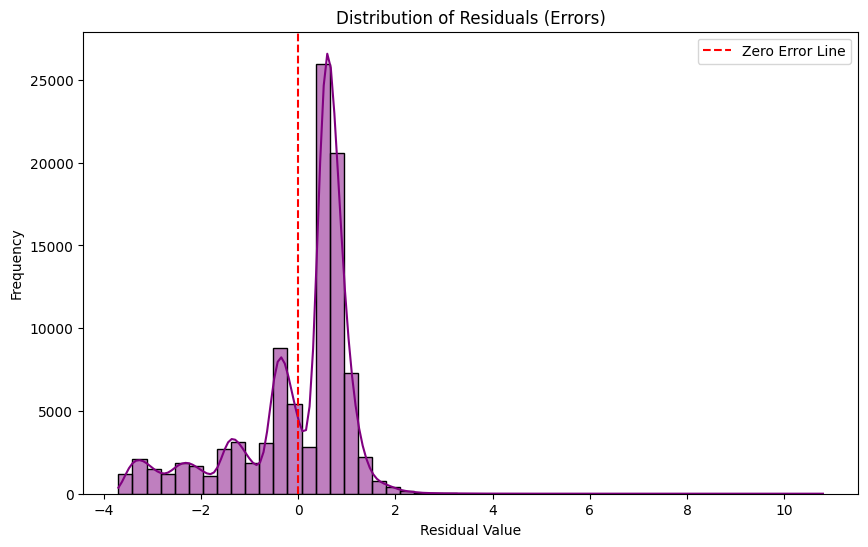

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=50, color='purple')
plt.title('Distribution of Residuals (Errors)')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--', label='Zero Error Line')
plt.legend()
plt.show()

❓ Kalıntıların distplot'unun neden bu kadar garip bir şekle sahip olduğunu tahmin edebilir misiniz?

*İpucu:*<br/>
👉 Aynı grafik üzerinde hem `review_score`'un dağılımını hem de `predicted_review_score`'un dağılımını çizin.

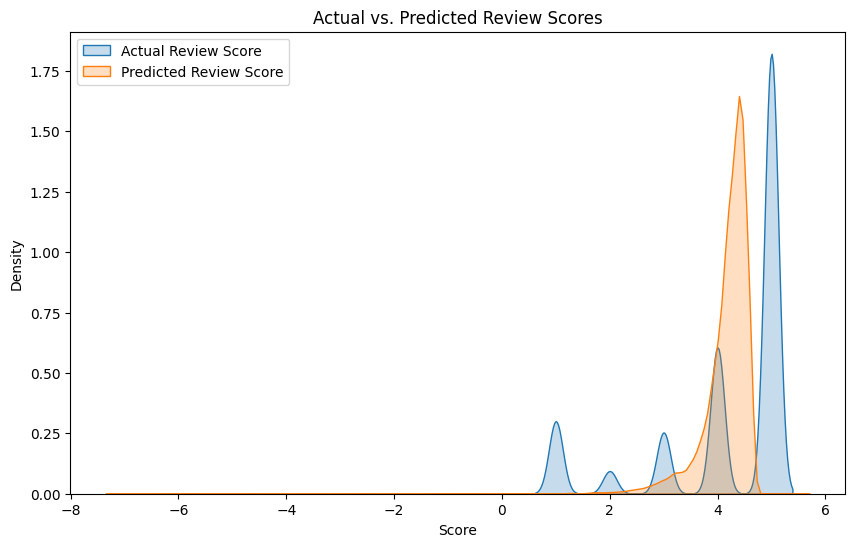

In [30]:
predicted_scores = model4.fittedvalues

plt.figure(figsize=(10, 6))
sns.kdeplot(features['review_score'], label='Actual Review Score', fill=True)
sns.kdeplot(predicted_scores, label='Predicted Review Score', fill=True)

plt.title('Actual vs. Predicted Review Scores')
plt.xlabel('Score')
plt.ylabel('Density')
plt.legend()
plt.show()

📈 Aslında, önceki zorlukta `review_score`'un `delay_vs_expected`'e karşı `regresyon çizgisi`'ni zaten çizmiştik.

Bu çizimi yeniden görselleştirmek için aşağıdaki hücreyi çalıştırın:

(0.0, 5.942630420124192)

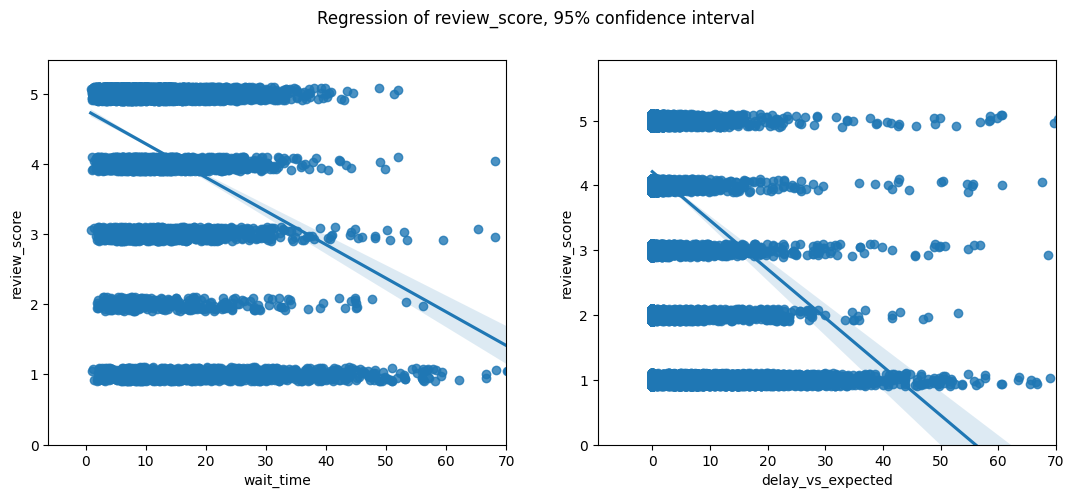

In [31]:
sample = orders.sample(10000, random_state=42)
plt.figure(figsize=(13,5))
plt.suptitle('Regression of review_score, 95% confidence interval')
plt.subplot(1,2,1)
sns.regplot(x = sample.wait_time, y= sample.review_score, y_jitter=.1, ci=95)
plt.xlim(right=70)
plt.ylim(bottom=0)

plt.subplot(1,2,2)
sns.regplot(x = orders.delay_vs_expected, y= orders.review_score, y_jitter=.1, ci=95)
plt.xlim(right=70)
plt.ylim(bottom=0)

☝️ Bir siparişin `review_score`'unu onun `wait_time` veya `delay_vs_expected`'ine karşı regrese etmenin zor olduğunu görebilirsiniz çünkü `review_score` ayrı bir sayı olup aynı zamanda bir kategori olarak da yorumlanabilir: 1 (çok kötü), 2 (kötü), 3 (orta), 4 (iyi), 5 (mükemmel).

📅 Sonraki ünitede, adına rağmen bir `Classification Algorithm` olan yeni bir model keşfedeceksiniz: `Logistic Regression` 

☝️ Sonuç olarak, modelimiz iki nedenden dolayı o kadar harika değil:
- İlk olarak, review_scores'un önemli bir kısmını açıklamak için yeterli özelliğimiz olmadığı için (düşük R-squared)
- İkinci olarak, "doğrusal regresyon" işlevini ayrı bir sınıflandırma problemine uydurmaya çalıştığımız için

💡 Bireysel siparişler üzerinde çalışmak ve `wait_time` tabanlı ayrı `review_score`'ları açıklamaya çalışmak yerine, bir sonraki zorlukta siparişleri satıcılar tarafından toplayarak analiz edilmesini satıcı seviyesine yoğunlaştıracağız.

🏁 Harika iş!

💾 İşiniz bittiğinde bu not defterini *kaydetmeyi*, *commit* ve *push* etmeyi unutmayın!